# Task 7 - SVM - Bayes
After recent natural disasters, the government decided to improve the prevention and evacuation system with the help of posts from X (Twitter). More specifically, the system will examine posts and in case it determines that a natural disaster (target=1) is in progress, it will send an appropriate message via 112.


## Libraries

In [49]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
from functools import partial
from google.colab import drive
from collections import Counter
import matplotlib.pyplot as plt
from IPython.display import display

import nltk
from nltk.corpus import wordnet
from nltk.corpus import stopwords
from sklearn.svm import LinearSVC
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer

from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

## Connect with google drive to import dataset

In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Questions 1:
Download the training/test datasets train.csv and split the dataset into train-test (90-10%) with the stratify option and random_state=0.
https://www.kaggle.com/competitions/nlp-getting-started. Then, create a bar-plot with the number of targets in train, test respectively. Is the dataset balanced?

In [4]:
# Get the datasets
train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/NLP-Disaster Tweets train.csv')
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/NLP-Disaster Tweets test.csv')

# Print datsets and shapes
print(f"Shape of train set: {train.shape}")
display(train.head(5))

print(f"\n\nShape of test set: {test.shape}")
display(test.head(5))

# Train test split
X = train.drop('target', axis=1)
y = train['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0, stratify=y)

print("\n\n\n")
print("*"*40)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print("*"*40)
print(f"Shape of X_train: {X_test.shape}")
print(f"Shape of y_train: {y_test.shape}")
print("*"*40)

Shape of train set: (7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1




Shape of test set: (3263, 4)


,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan






****************************************
Shape of X_train: (6851, 4)
Shape of y_train: (6851,)
****************************************
Shape of X_train: (762, 4)
Shape of y_train: (762,)
****************************************


### Is the dataset Balanced ?
In training set target is just a little unbalanced since the number of zeros are 3907(57%) and number of ones are 2944(43%).


Since we use stratify=y then the feature target is equally distributed and so test set is a little unbalanced too with the same proportions in labels ones and zeros.

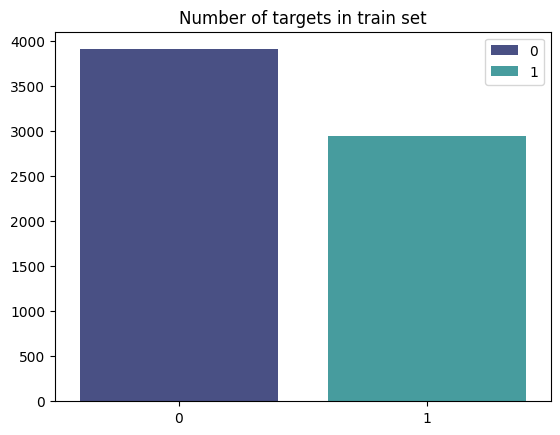

train_names: [0 1]
train_count: [3907 2944]


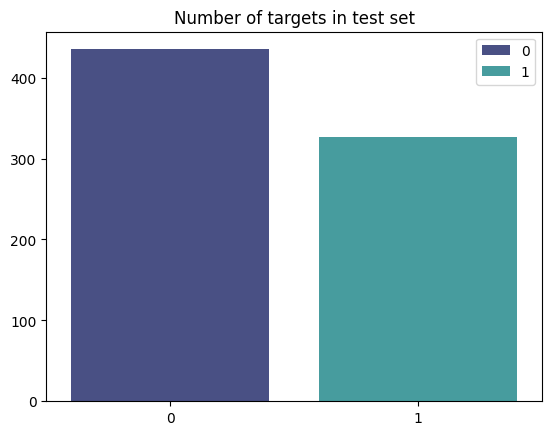

test_names: [0 1]
test_count: [435 327]


In [5]:
# Bar plots for train
train_names, train_count = np.unique(y_train, return_counts=True)
sns.barplot(x=train_names, y=train_count, palette = 'mako', hue=train_names)
plt.title('Number of targets in train set')
plt.show()
print(f"train_names: {train_names}")
print(f"train_count: {train_count}")


# Bar plots for test
test_names, test_count = np.unique(y_test, return_counts=True)
sns.barplot(x=test_names, y=test_count, palette = 'mako', hue=test_names)
plt.title('Number of targets in test set')
plt.show()
print(f"test_names: {test_names}")
print(f"test_count: {test_count}")

## Question 2:
Process the train/test data as follows:
- Remove the id, location attributes.
- Fill in the missing values ​​with the keyword “null”.
- Join the keyword and text columns as: df[‘inputs’] = df[‘keyword’] + ‘ ‘ + df[‘text’].

In [6]:
# Remove the id, location attributes
X_train = X_train.drop(['id', 'location'], axis=1)
X_test = X_test.drop(['id', 'location'], axis=1)

# Fill in the missin values with the keyword "null"
X_train.fillna('null', inplace=True)
X_test.fillna('null', inplace=True)

# Join the keyword and text columns as: df[‘inputs’] = df[‘keyword’] + ‘ ‘ + df[‘text’].
X_train['inputs'] = X_train['keyword'] + ' ' + X_train['text']
X_test['inputs'] = X_test['keyword'] + ' ' + X_test['text']

display(X_train.head(5))
print("\n\n")
display(X_test.head(5))

,keyword,text,inputs
6669,threat,Meek Mill responds to DrakeÛªs OVO Fest set w...,threat Meek Mill responds to DrakeÛªs OVO Fes...
3940,flood,survived the plague\nfloated the flood\njust p...,flood survived the plague\nfloated the flood\n...
7217,weapons,#Kick Hendrixonfire @'=BLACKCATS= | BIG NOOB ...,weapons #Kick Hendrixonfire @'=BLACKCATS= | B...
2234,deluge,Vince McMahon once again a billionaire: I reme...,deluge Vince McMahon once again a billionaire:...
4233,hazardous,Is it possible to sneak into a hospital so I c...,hazardous Is it possible to sneak into a hospi...


,keyword,text,inputs
604,bioterror,#FedEx no longer to transport bioterror germs ...,bioterror #FedEx no longer to transport bioter...
5374,panic,Panic over: Patient in Alabama tests negative ...,panic Panic over: Patient in Alabama tests neg...
3022,dust%20storm,New Mad Max Screenshots Show Off a Lovely Dust...,dust%20storm New Mad Max Screenshots Show Off ...
3357,evacuated,Rocky fire in Northern California swells to 60...,evacuated Rocky fire in Northern California sw...
4726,lava,@YoungHeroesID Lava Blast &amp; Power Red @die...,lava @YoungHeroesID Lava Blast &amp; Power Red...


## Question 3
Process the tweet texts (inputs) in train, test, in order to remove all unnecessary information (e.g. symbols, emoji, etc.). Use the ready-made implemented functions that you will find in the following repository: https://github.com/Deffro/text-preprocessing-techniques/tree/master?tab=readme-ov-file#0-remove-unicode-strings-and-noise. Briefly describe (in 1 line) each technique you used and justify the reason for choosing the specific techniques.

---
**Ready functions I use:**

- removeUnicode: remove unicode characters since there is no information when they are read and they are misinformation

- replaceURL: Url is just a link. Most of the times it is not usefull but something like this http://t.co/qqSKYbARNg (from a real dataset example)

---
Most of the special characters are useless since they are not providing information except from: '?', '!', '%' and maybe even more, but these are important to keep

**Removed special charactes:**

- replaceAtUser
- removeHashtagInFrontOfWord
- replaceMultiExclamationMark(one is enough)
- replaceMultiQuestionMark(one is enough)
- replaceMultiStopMark(more than one might be mistaken or meaning something like ... which might be difficult for the model to get trained on)





In [7]:
def removeUnicode(text):
    """ Removes unicode strings like "\u002c" and "x96" """
    text = re.sub(r'(\\u[0-9A-Fa-f]+)',r'', text)
    text = re.sub(r'[^\x00-\x7f]',r'',text)
    return text

def replaceURL(text):
    """ Replaces url address with "url" """
    text = re.sub('((www\.[^\s]+)|(https?://[^\s]+))','url',text)
    text = re.sub(r'#([^\s]+)', r'\1', text)
    return text

def replaceAtUser(text):
    """ Replaces "@user" with "atUser" """
    text = re.sub('@[^\s]+','atUser',text)
    return text

def removeHashtagInFrontOfWord(text):
    """ Removes hastag in front of a word """
    text = re.sub(r'#([^\s]+)', r'\1', text)
    return text

def replaceMultiExclamationMark(text):
    """ Replaces repetitions of exlamation marks """
    text = re.sub(r"(\!)\1+", ' multiExclamation ', text)
    return text

def replaceMultiQuestionMark(text):
    """ Replaces repetitions of question marks """
    text = re.sub(r"(\?)\1+", ' multiQuestion ', text)
    return text

def replaceMultiStopMark(text):
    """ Replaces repetitions of stop marks """
    text = re.sub(r"(\.)\1+", ' multiStop ', text)
    return text


<>:9: SyntaxWarning: invalid escape sequence '\.'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\.'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1594141489.py:9: SyntaxWarning: invalid escape sequence '\.'
  text = re.sub('((www\.[^\s]+)|(https?://[^\s]+))','url',text)
/tmp/ipython-input-1594141489.py:15: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('@[^\s]+','atUser',text)


### Make a test to ensure everything is working fine

In [8]:
# Get the first text in the list
text = 'threat Meek Mill responds to Drake\x89Ûªs OVO Fest set with.... wedgie threat http://t.co/qqSKYbARNg'

# Make a list with all functions
functions = [
    removeUnicode,
    replaceURL,
    replaceAtUser,
    removeHashtagInFrontOfWord,
    replaceMultiExclamationMark,
    replaceMultiQuestionMark,
    replaceMultiStopMark
]

# For loop to use all functions
for i in functions:
  text = i(text)

print(text)

threat Meek Mill responds to Drakes OVO Fest set with multiStop  wedgie threat url


In [9]:
train

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


In [10]:
# For loop to use all functions
for i in functions:
  X_train['inputs'] = X_train['inputs'].apply(i)
  X_test['inputs'] = X_test['inputs'].apply(i)

# Display resutls
display(X_train.head(5))
display(X_test.head(5))

,keyword,text,inputs
6669,threat,Meek Mill responds to DrakeÛªs OVO Fest set w...,threat Meek Mill responds to Drakes OVO Fest s...
3940,flood,survived the plague\nfloated the flood\njust p...,flood survived the plague\nfloated the flood\n...
7217,weapons,#Kick Hendrixonfire @'=BLACKCATS= | BIG NOOB ...,weapons Kick Hendrixonfire atUser | BIG NOOB ...
2234,deluge,Vince McMahon once again a billionaire: I reme...,deluge Vince McMahon once again a billionaire:...
4233,hazardous,Is it possible to sneak into a hospital so I c...,hazardous Is it possible to sneak into a hospi...


,keyword,text,inputs
604,bioterror,#FedEx no longer to transport bioterror germs ...,bioterror FedEx no longer to transport bioterr...
5374,panic,Panic over: Patient in Alabama tests negative ...,panic Panic over: Patient in Alabama tests neg...
3022,dust%20storm,New Mad Max Screenshots Show Off a Lovely Dust...,dust%20storm New Mad Max Screenshots Show Off ...
3357,evacuated,Rocky fire in Northern California swells to 60...,evacuated Rocky fire in Northern California sw...
4726,lava,@YoungHeroesID Lava Blast &amp; Power Red @die...,lava atUser Lava Blast &amp; Power Red atUser ...


## Question 4
Separate the data into inputs, targets (numpy arrays).

In [11]:
# Separate the data into inputs, targets (numpy arrays).
X_train = X_train['inputs'].to_numpy()
y_train = y_train.to_numpy()
X_test = X_test['inputs'].to_numpy()
y_test = y_test.to_numpy()

## Question 5
Transform the inputs as follows: For each post, calculate the tf-idf of each word. Use the scikit-learn TfIDFVectorizer class: https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html. You will need to apply fit_transform for the train set and plain transform for the test set.

In [12]:
# Initialize TfidfVectorizer
vectorizer = TfidfVectorizer()

# Apply to training and test set
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

## Question 6
Train an SVM classifier with a linear Kernel (LinearSVC) https://scikit-learn.org/dev/modules/generated/sklearn.svm.LinearSVC.html on the train and measure for the train and test sets: Accuracy, F1, Precision, Recall.
Which metric is more important? Justify.

#### Which metric is more important

In this case Recall is more important since we want to warn people if a distaster is going to happen instead of mis a case.

- Better to sent 112 when nothing will happen, instead of not sending the message and something actually happens.

In [26]:
linear_svc = LinearSVC()
linear_svc.fit(X_train, y_train)
train_y_pred = linear_svc.predict(X_train)
test_y_pred = linear_svc.predict(X_test)

In [27]:

print("======== Classification report for train set ========\n ")
print(classification_report(y_train, train_y_pred))
print("\n\n======== Classification report for test set ========\n ")
print(classification_report(y_test, test_y_pred))

======== Classification report for train set ========
 
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      3907
           1       0.98      0.94      0.96      2944

    accuracy                           0.96      6851
   macro avg       0.97      0.96      0.96      6851
weighted avg       0.96      0.96      0.96      6851



======== Classification report for test set ========
 
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       435
           1       0.78      0.74      0.76       327

    accuracy                           0.80       762
   macro avg       0.79      0.79      0.79       762
weighted avg       0.80      0.80      0.80       762



In [15]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 94546 stored elements and shape (6851, 14166)>

## Question 7
Apply PCA transformation to the data, keeping 95% of the useful information (be careful not to lose the components!). Then, train LinearSVC and SVC with RBF kernel https://scikit-learn.org/dev/modules/generated/sklearn.svm.SVC.html and compare their performances.

I use TruncatedSVD because TF_IDF representation results in a high-dimenional sparse matrix. PCA was applied using TruncatedSVD which is for sparse data. After many trying using:

```
info_kept = np.sum(svd.explained_variance_ratio_)
print(info_kept)
```
I found that 4000 n_components keeps the 95% of the useful information.

*I deleted by mistake the code block which I found the 95%. It was just a for loop with values from 1000 to 5000 with 500 as a step. I was printing the results and this is how I got the number(It took way too many hours to run it again)*

In [22]:
# # Apply PCA
svd = TruncatedSVD(n_components=4000, random_state=42)
X_train_pca = svd.fit_transform(X_train)
X_test_pca = svd.transform(X_test)

# Train Linear SVC
pca_linear_svc = LinearSVC()
pca_linear_svc.fit(X_train_pca, y_train)
train_y_pred = pca_linear_svc.predict(X_train_pca)
test_y_pred = pca_linear_svc.predict(X_test_pca)
print("======== Linear SVC Classification report for train set ========\n\n ")
print(classification_report(y_train, train_y_pred))
print("\n\n======== Linear SVC Classification report for test set ========\n\n ")
print(classification_report(y_test, test_y_pred))

# Train SVC
svc_scaled = SVC(kernel='rbf')
svc_scaled.fit(X_train_pca, y_train)
train_y_pred = svc_scaled.predict(X_train_pca)
test_y_pred = svc_scaled.predict(X_test_pca)
print("======== SVC Classification report for train set ========\n\n ")
print(classification_report(y_train, train_y_pred))
print("\n\n======== SVC Classification report for test set ========\n\n ")
print(classification_report(y_test, test_y_pred))

KeyboardInterrupt: 

## Question 8
What is the value of the parameter γ (Gamma) used as the default ‘scale’ and what is the value ‘auto’? Change the parameter γ to ‘auto’ and retrain the SVC. Finally, create a bar-plot comparing the accuracy, F1, precision, recall metrics of the four trained models.

---
Gamma value is how big is the decision boundary, meaning that when gamma value is big then the model is more smooth with generic decision boundary. Instead when gamma is big then model is complicated "stacked" to the data (overfitting).

**Gamma = scale** is the formula  $ \frac{1} {(n_features * X.var())} $. This means the gamma value depends on feature number and the variation of the data. By that the data are dependent and more stable (this is why it is default value in scikit-learn)

**Gamma = auto** is less complex $ \frac{1}{n_features} $. Ignores the variance of the data and it depends only the number of features. It leads to bigger Gamma value meaning the model is more "Offensive" not so smooth.


**Explain the results: Model fit in class zero and ignores completly class 1. Becuase of the gamma value = auto the model overfit to the most common value (which shown before is the 0).**

In [21]:
# Initialize SVC with rbf kernel and gamma = auto
svc_auto = SVC(kernel='rbf', gamma='auto')
svc_auto.fit(X_train_pca, y_train)
train_y_pred = svc_auto.predict(X_train_pca)
test_y_pred = svc_auto.predict(X_test_pca)
print("======== SVC Classification report for train set ========\n\n ")
print(classification_report(y_train, train_y_pred))
print("\n\n======== SVC Classification report for test set ========\n\n ")
print(classification_report(y_test, test_y_pred))



======== SVC Classification report for train set ========

 
              precision    recall  f1-score   support

           0       0.57      1.00      0.73      3907
           1       0.00      0.00      0.00      2944

    accuracy                           0.57      6851
   macro avg       0.29      0.50      0.36      6851
weighted avg       0.33      0.57      0.41      6851



======== SVC Classification report for test set ========

 
              precision    recall  f1-score   support

           0       0.57      1.00      0.73       435
           1       0.00      0.00      0.00       327

    accuracy                           0.57       762
   macro avg       0.29      0.50      0.36       762
weighted avg       0.33      0.57      0.41       762



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

### Bar plot for recall/precision/accuracy/f1_score for 4 different models

In [29]:
yyyy = linear_svc.predict(X_test)
acc = accuracy_score(y_test, yyyy)
print(acc)

0.7965879265091863


In [32]:
models = {
    "LinearSVC": linear_svc,
    "PCA + LinearSVC": pca_linear_svc,
    "PCA + SVC (scale)": svc_scaled,
    "PCA + SVC (auto)": svc_auto
}

results = {}

for name, model in models.items():
  if name == 'LinearSVC':
    y_pred = model.predict(X_test)
  else:
    y_pred = model.predict(X_test_pca)

  results[name] = {
      "test_Accuracy": accuracy_score(y_test, y_pred),
      "train_Accuracy": accuracy_score(y_train, train_y_pred),
      "test_Precision": precision_score(y_test, y_pred),
      "train_Precision": precision_score(y_train, train_y_pred),
      "test_Recall": recall_score(y_test, y_pred),
      "train_Recall": recall_score(y_train, train_y_pred),
      "train_F1": f1_score(y_train, train_y_pred),
      "test_F1": f1_score(y_test, y_pred)
  }
results

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'LinearSVC': {'test_Accuracy': 0.7965879265091863,
  'train_Accuracy': 0.963363012698876,
  'test_Precision': 0.7774193548387097,
  'train_Precision': 0.9776516495211067,
  'test_Recall': 0.7370030581039755,
  'train_Recall': 0.936141304347826,
  'train_F1': 0.9564462953322922,
  'test_F1': 0.7566718995290423},
 'PCA + LinearSVC': {'test_Accuracy': 0.8057742782152231,
  'train_Accuracy': 0.963363012698876,
  'test_Precision': 0.7877813504823151,
  'train_Precision': 0.9776516495211067,
  'test_Recall': 0.7492354740061162,
  'train_Recall': 0.936141304347826,
  'train_F1': 0.9564462953322922,
  'test_F1': 0.768025078369906},
 'PCA + SVC (scale)': {'test_Accuracy': 0.8123359580052494,
  'train_Accuracy': 0.963363012698876,
  'test_Precision': 0.8006535947712419,
  'train_Precision': 0.9776516495211067,
  'test_Recall': 0.7492354740061162,
  'train_Recall': 0.936141304347826,
  'train_F1': 0.9564462953322922,
  'test_F1': 0.7740916271721959},
 'PCA + SVC (auto)': {'test_Accuracy': 0.5708

### Make bar plots

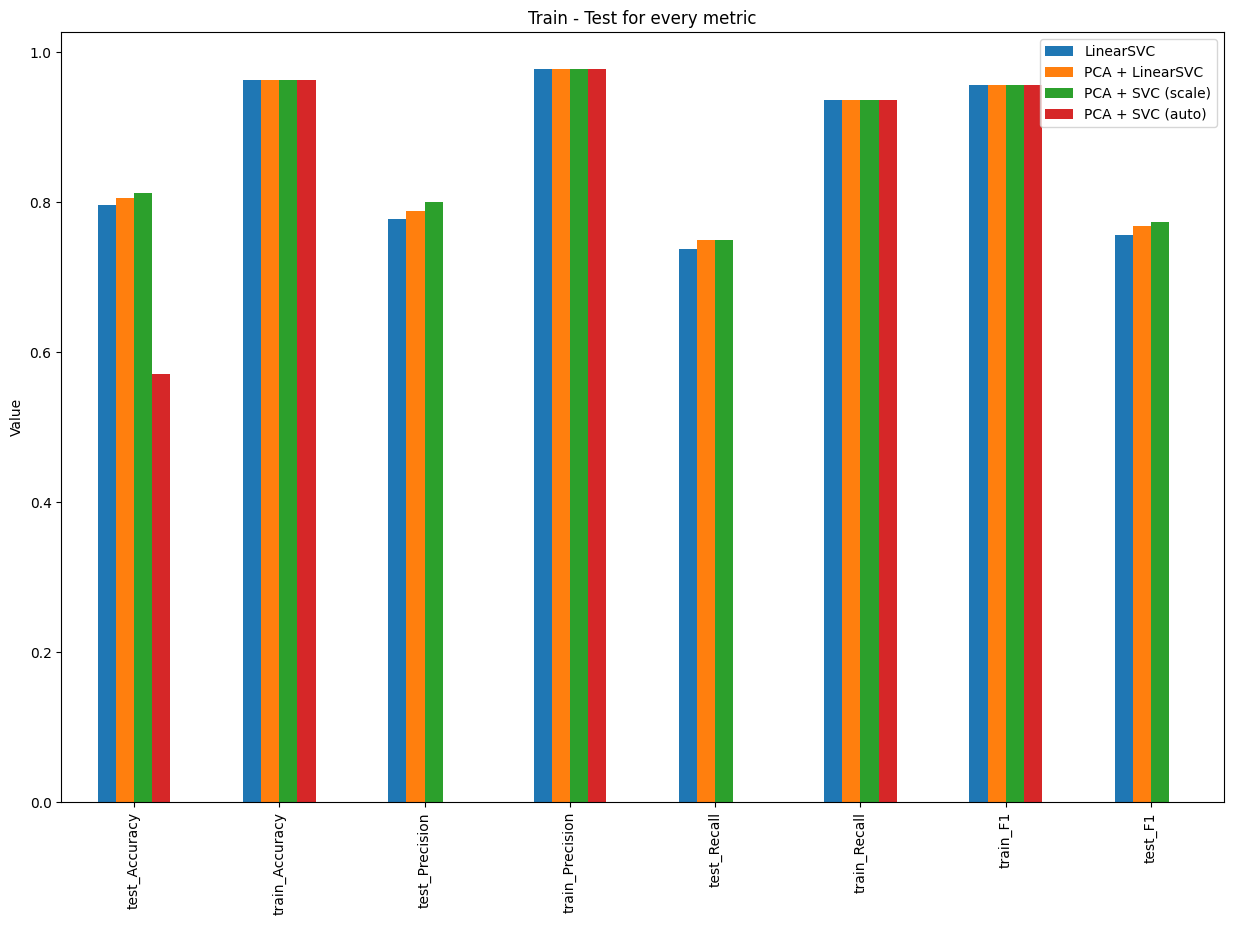

In [47]:
# Put list into df
df = pd.DataFrame(results)
ax = df.plot(kind='bar', title ="Train - Test for every metric", figsize=(15, 10), legend=True)
ax.set_ylabel("Value")
plt.show()

## Question 9
Repeat question 6 (before applying the PCA transformation) using Gaussian Naive Bayes:
https://scikit-learn.org/dev/modules/generated/sklearn.naive_bayes.GaussianNB.html

Because of this error:

```
TypeError: Sparse data was passed for X, but dense data is required. Use '.toarray()' to convert to a dense numpy array.
```

I found that GaussianNB is not working with Sparse data and so I convert my data into arrays

Results of the GaussianNB are not as good as Liner SVC. In training set it has great results but in test set it is very low

In [52]:
# Conevrt sparse to array
X_train = X_train.toarray()
X_test = X_test.toarray()

In [53]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [54]:
train_y_pred = gnb.predict(X_train)
test_y_pred = gnb.predict(X_test)
print("======== Classification report for train set ========\n ")
print(classification_report(y_train, train_y_pred))
print("\n\n======== Classification report for test set ========\n ")
print(classification_report(y_test, test_y_pred))

======== Classification report for train set ========
 
              precision    recall  f1-score   support

           0       1.00      0.79      0.89      3907
           1       0.79      1.00      0.88      2944

    accuracy                           0.88      6851
   macro avg       0.89      0.90      0.88      6851
weighted avg       0.91      0.88      0.88      6851



======== Classification report for test set ========
 
              precision    recall  f1-score   support

           0       0.76      0.49      0.60       435
           1       0.54      0.80      0.64       327

    accuracy                           0.62       762
   macro avg       0.65      0.64      0.62       762
weighted avg       0.67      0.62      0.62       762

